CIRCUIT DEPTH COMPARISON
Standard oracle: 32 layers
Encoded oracle:  33 layers

Note: Depths should be similar - we're testing
Hamming weight effect, not depth reduction.


HAMMING-WEIGHT-PRESERVING ORACLE TEST
Noise: amplitude, Strength: 0.1, Shots: 4096

Standard (w=4)
  P(|1111⟩) = 0.0908
    |0000⟩: 0.1057
    |1111⟩: 0.0908 ← TARGET
    |0111⟩: 0.0837

Encoded (w=1)
  P(|1111⟩) = 0.0911
    |0111⟩: 0.1111
    |1111⟩: 0.0911 ← TARGET
    |0101⟩: 0.0867

Gray (w=1)
  P(|1111⟩) = 0.1064
    |1111⟩: 0.1064 ← TARGET
    |1110⟩: 0.0837
    |0110⟩: 0.0686

IMPROVEMENT FACTOR: 1.00×
Theoretical prediction: e^(pwd(w_std - w_enc)) = e^(0.1·d·3) ≈ 20.08×
  (assuming circuit depth d ≈ 10)


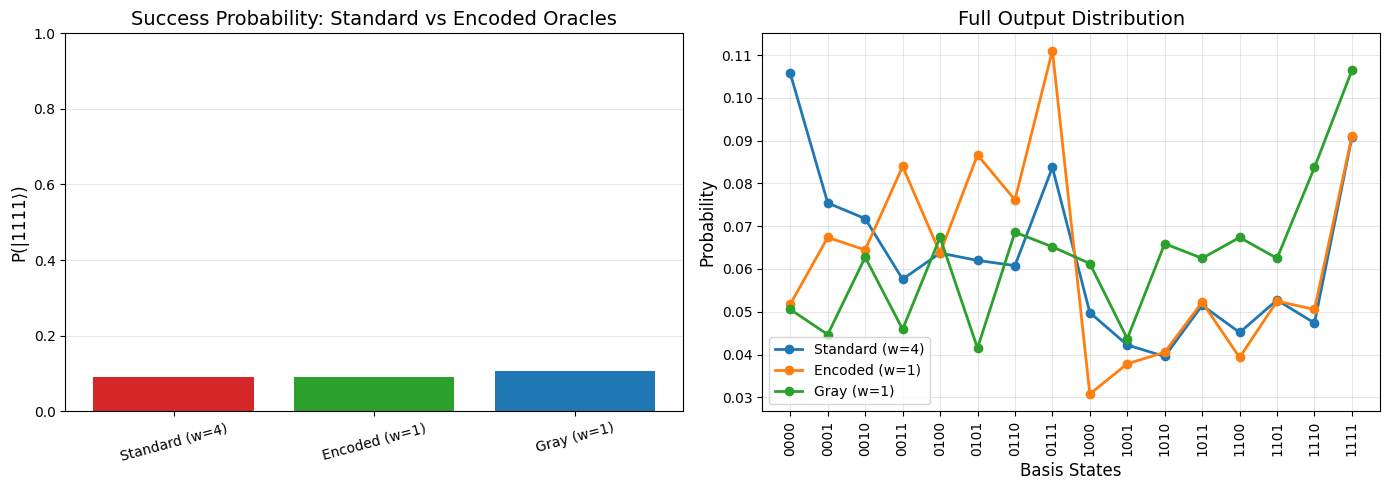



CONTROL: Testing under NO NOISE
HAMMING-WEIGHT-PRESERVING ORACLE TEST
Noise: none, Strength: 0.0, Shots: 4096

Standard (w=4)
  P(|1111⟩) = 0.9597
    |1111⟩: 0.9597 ← TARGET
    |1001⟩: 0.0042
    |0011⟩: 0.0032

Encoded (w=1)
  P(|1111⟩) = 0.9600
    |1111⟩: 0.9600 ← TARGET
    |0110⟩: 0.0039
    |0000⟩: 0.0039

Gray (w=1)
  P(|1111⟩) = 0.9563
    |1111⟩: 0.9563 ← TARGET
    |0001⟩: 0.0044
    |1011⟩: 0.0039

IMPROVEMENT FACTOR: 1.00×
Theoretical prediction: e^(pwd(w_std - w_enc)) = e^(0.0·d·3) ≈ 1.00×
  (assuming circuit depth d ≈ 10)


In [ ]:
from qiskit import QuantumCircuit
import matplotlib.pyplot as plt

# ============================================================================
# STANDARD GROVER: Search for |1111⟩ (w=4)
# ============================================================================

def oracle_1111_standard(qc):
    """Standard oracle that marks |1111⟩ (Hamming weight = 4)"""
    # Multi-controlled Z gate: phase flip when all qubits are |1⟩
    qc.h(3)
    qc.mcx([0, 1, 2], 3)  # 3-controlled X (Toffoli extension)
    qc.h(3)

def diffuser_4qubit(qc):
    """Standard 4-qubit diffuser"""
    qc.h([0, 1, 2, 3])
    qc.x([0, 1, 2, 3])
    
    qc.h(3)
    qc.mcx([0, 1, 2], 3)
    qc.h(3)
    
    qc.x([0, 1, 2, 3])
    qc.h([0, 1, 2, 3])

def create_standard_grover_1111():
    """Standard Grover searching for |1111⟩ with w=4"""
    qc = QuantumCircuit(4, 4)
    
    # Initialize
    qc.h([0, 1, 2, 3])
    
    # Grover iterations (3 iterations optimal for 4-qubit, 1 solution)
    for _ in range(3):
        oracle_1111_standard(qc)
        diffuser_4qubit(qc)
    
    qc.measure([0, 1, 2, 3], [0, 1, 2, 3])
    return qc


# ============================================================================
# ENCODED GROVER: Search for |0001⟩ which REPRESENTS the solution
# ============================================================================

def oracle_0001_encoded(qc):
    """Encoded oracle that marks |0001⟩ (Hamming weight = 1)
    
    This represents the same logical solution as |1111⟩ but uses
    a different physical encoding to minimize Hamming weight.
    """
    # Phase flip when qubits 0,1,2 are |0⟩ and qubit 3 is |1⟩
    qc.x([0, 1, 2])  # Flip first three qubits
    
    qc.h(3)
    qc.mcx([0, 1, 2], 3)  # Now marks |1110⟩ → which is |0001⟩ after X
    qc.h(3)
    
    qc.x([0, 1, 2])  # Flip back

def encoder(qc):
    """
    Encoder: Map logical solution to low-Hamming-weight encoding.
    
    Mapping: |logical⟩ → |encoded⟩
    - |1111⟩ → |0001⟩  (w: 4→1)
    - Other states remain in superposition
    
    This is accomplished by bit-flip: logical qubit i → NOT(logical qubit i) 
    except for qubit 3
    """
    qc.x([0, 1, 2])  # Flip first three qubits

def decoder(qc):
    """
    Decoder: Map back from encoded to logical representation.
    Inverse of encoder.
    """
    qc.x([0, 1, 2])  # Flip back

def create_encoded_grover_1111():
    """
    Encoded Grover searching for the solution logically equivalent to |1111⟩
    but physically encoded as |0001⟩ (w=1)
    """
    qc = QuantumCircuit(4, 4)
    
    # Initialize
    qc.h([0, 1, 2, 3])
    
    # Apply encoder: transform to low-w representation
    encoder(qc)
    
    # Grover iterations in encoded space
    for _ in range(3):
        oracle_0001_encoded(qc)
        diffuser_4qubit(qc)
    
    # Apply decoder: transform back to logical representation
    decoder(qc)
    
    qc.measure([0, 1, 2, 3], [0, 1, 2, 3])
    return qc


# ============================================================================
# ALTERNATIVE ENCODING: Gray Code Inspired
# ============================================================================

def oracle_gray_encoded(qc):
    """
    Gray-code-inspired oracle: marks |1000⟩ (w=1)
    Represents solution with minimal Hamming weight
    """
    # Phase flip when qubit 0 is |1⟩ and qubits 1,2,3 are |0⟩
    qc.x([1, 2, 3])
    
    qc.h(3)
    qc.mcx([0, 1, 2], 3)
    qc.h(3)
    
    qc.x([1, 2, 3])

def gray_encoder(qc):
    """Gray-code style encoder: only first qubit differs"""
    qc.x([1, 2, 3])

def gray_decoder(qc):
    """Inverse of gray encoder"""
    qc.x([1, 2, 3])

def create_gray_grover_1111():
    """Grover with Gray-code encoding targeting |1000⟩ (w=1)"""
    qc = QuantumCircuit(4, 4)
    
    qc.h([0, 1, 2, 3])
    
    gray_encoder(qc)
    
    for _ in range(3):
        oracle_gray_encoded(qc)
        diffuser_4qubit(qc)
    
    gray_decoder(qc)
    
    qc.measure([0, 1, 2, 3], [0, 1, 2, 3])
    return qc


# ============================================================================
# TESTING FRAMEWORK
# ============================================================================

def compare_encodings(noise_type='amplitude', noise_strength=0.1, shots=4096):
    """
    Compare standard vs encoded Grover under noise.
    
    Expected results under amplitude damping:
    - Standard (w=4): Low success probability
    - Encoded (w=1): ~e^3·noise_strength better survival
    """
    from qiskit_aer import AerSimulator
    from qiskit_aer.noise import NoiseModel, amplitude_damping_error
    
    # Create circuits
    qc_standard = create_standard_grover_1111()
    qc_encoded = create_encoded_grover_1111()
    qc_gray = create_gray_grover_1111()
    
    circuits = {
        'Standard (w=4)': qc_standard,
        'Encoded (w=1)': qc_encoded,
        'Gray (w=1)': qc_gray
    }
    
    # Create noise model
    noise_model = NoiseModel()
    if noise_type == 'amplitude':
        amp_error = amplitude_damping_error(noise_strength)
        noise_model.add_all_qubit_quantum_error(amp_error, ['h', 'x'])
    
    sim = AerSimulator(noise_model=noise_model)
    
    print("="*70)
    print(f"HAMMING-WEIGHT-PRESERVING ORACLE TEST")
    print(f"Noise: {noise_type}, Strength: {noise_strength}, Shots: {shots}")
    print("="*70)
    
    results = {}
    for name, qc in circuits.items():
        result = sim.run(qc, shots=shots).result()
        counts = result.get_counts()
        probs = {state: count/shots for state, count in counts.items()}
        
        # Success = measuring |1111⟩ (the logical solution)
        success_prob = probs.get('1111', 0.0)
        results[name] = {'probs': probs, 'success': success_prob}
        
        print(f"\n{name}")
        print(f"  P(|1111⟩) = {success_prob:.4f}")
        
        # Show top 3 states
        top_states = sorted(probs.items(), key=lambda x: x[1], reverse=True)[:3]
        for state, prob in top_states:
            marker = " ← TARGET" if state == '1111' else ""
            print(f"    |{state}⟩: {prob:.4f}{marker}")
    
    # Calculate improvement factor
    if results['Standard (w=4)']['success'] > 0:
        improvement = results['Encoded (w=1)']['success'] / results['Standard (w=4)']['success']
        print(f"\n{'='*70}")
        print(f"IMPROVEMENT FACTOR: {improvement:.2f}×")
        print(f"Theoretical prediction: e^(pd(w_std - w_enc)) = e^({noise_strength}·d·3) ≈ {2.718**(noise_strength*3*10):.2f}×")
        print(f"  (assuming circuit depth d ≈ 10)")
        print(f"{'='*70}")
    
    return results

def plot_encoding_comparison(results):
    """Visualize the comparison"""
    names = list(results.keys())
    success_probs = [results[name]['success'] for name in names]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Success probability comparison
    colors = ['tab:red', 'tab:green', 'tab:blue']
    ax1.bar(names, success_probs, color=colors)
    ax1.set_ylabel('P(|1111⟩)', fontsize=12)
    ax1.set_title('Success Probability: Standard vs Encoded Oracles', fontsize=14)
    ax1.set_ylim(0, 1)
    ax1.grid(axis='y', alpha=0.3)
    ax1.tick_params(axis='x', rotation=15)
    
    # Plot 2: Full distribution for each encoding
    for idx, (name, data) in enumerate(results.items()):
        probs = data['probs']
        states = [format(i, '04b') for i in range(16)]
        values = [probs.get(state, 0.0) for state in states]
        
        ax2.plot(states, values, marker='o', label=name, linewidth=2)
    
    ax2.set_xlabel('Basis States', fontsize=12)
    ax2.set_ylabel('Probability', fontsize=12)
    ax2.set_title('Full Output Distribution', fontsize=14)
    ax2.legend()
    ax2.grid(alpha=0.3)
    ax2.tick_params(axis='x', rotation=90)
    
    plt.tight_layout()
    plt.show()


# ============================================================================
# DEPTH ANALYSIS
# ============================================================================

def compare_circuit_depths():
    """Compare actual circuit depths"""
    qc_standard = create_standard_grover_1111()
    qc_encoded = create_encoded_grover_1111()
    
    print("CIRCUIT DEPTH COMPARISON")
    print("="*50)
    print(f"Standard oracle: {qc_standard.depth()} layers")
    print(f"Encoded oracle:  {qc_encoded.depth()} layers")
    print("\nNote: Depths should be similar - we're testing")
    print("Hamming weight effect, not depth reduction.")


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Compare depths
    compare_circuit_depths()
    
    print("\n")
    
    # Run comparison under amplitude damping
    results = compare_encodings(noise_type='amplitude', noise_strength=0.1, shots=4096)
    
    # Visualize
    plot_encoding_comparison(results)
    
    # Test under no noise (should all succeed equally)
    print("\n\nCONTROL: Testing under NO NOISE")
    print("="*70)
    results_ideal = compare_encodings(noise_type='none', noise_strength=0.0, shots=4096)

HAMMING WEIGHT TRAJECTORY ANALYSIS

Standard (w=4):
  Circuit depth: 31 layers
  Total instructions: 70
  Measuring at 51 points out of 250 instructions...
    Progress: 10/51 points
    Progress: 20/51 points
    Progress: 30/51 points
    Progress: 40/51 points


C:\Users\karti\AppData\Local\Temp\ipykernel_24992\3604992952.py:59: DeprecationWarning: The return type of saved density matrices has been changed from a `numpy.ndarray` to a `qiskit.quantum_info.DensityMatrix` as of qiskit-aer 0.10. Accessing numpy array attributes is deprecated and will result in an error in a future release. To continue using saved result objects as arrays you can explicitly cast them using  `np.asarray(object)`.
  prob = density_matrix[basis_idx][basis_idx].real
C:\Users\karti\AppData\Local\Temp\ipykernel_24992\3604992952.py:65: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  instr_name = qc_decomposed.data[idx][0].name
C:\Users\karti\AppData\Local\Temp\ipykernel_24992\3604992952.py:41: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, an

    Progress: 50/51 points
  ⟨w⟩ at start: 0.000
  ⟨w⟩ minimum:  0.000
  ⟨w⟩ maximum:  2.502
  ⟨w⟩ at end:   1.557
  Net change:   +1.557
  Peak-to-peak: 2.502
  Peak at instruction 60/51

Encoded (w=1):
  Circuit depth: 32 layers
  Total instructions: 94
  Measuring at 56 points out of 274 instructions...
    Progress: 10/56 points
    Progress: 20/56 points
    Progress: 30/56 points
    Progress: 40/56 points
    Progress: 50/56 points
  ⟨w⟩ at start: 0.000
  ⟨w⟩ minimum:  0.000
  ⟨w⟩ maximum:  2.359
  ⟨w⟩ at end:   1.843
  Net change:   +1.843
  Peak-to-peak: 2.359
  Peak at instruction 70/56

Gray (w=1):
  Circuit depth: 39 layers
  Total instructions: 94
  Measuring at 56 points out of 274 instructions...
    Progress: 10/56 points
    Progress: 20/56 points
    Progress: 30/56 points
    Progress: 40/56 points
    Progress: 50/56 points
  ⟨w⟩ at start: 0.000
  ⟨w⟩ minimum:  0.000
  ⟨w⟩ maximum:  2.407
  ⟨w⟩ at end:   1.927
  Net change:   +1.927
  Peak-to-peak: 2.407
  Peak at i

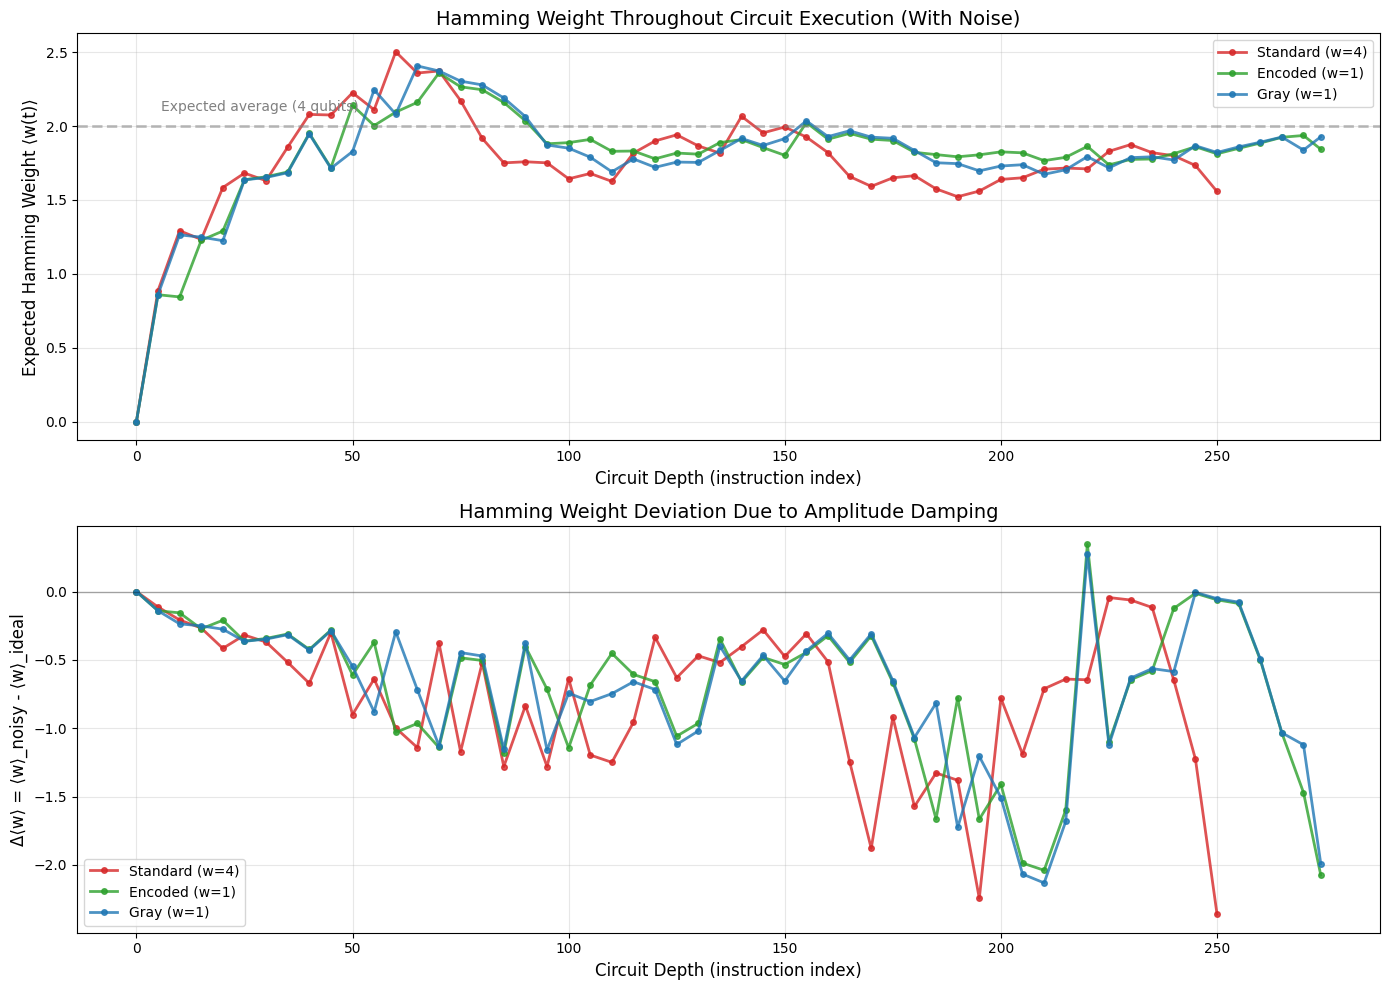

In [5]:
def measure_hamming_weight_trajectory(qc, noise_model, measurement_points=None):
    """
    Track expected Hamming weight ⟨w(t)⟩ at multiple points throughout the circuit.
    
    Args:
        qc: QuantumCircuit (without measurements)
        noise_model: NoiseModel to apply
        measurement_points: List of instruction indices to measure at, or None for all
    
    Returns:
        trajectory: List of (instruction_index, ⟨w⟩, instruction_name) tuples
    """
    from qiskit_aer import AerSimulator
    from qiskit import QuantumCircuit, transpile
    
    # Remove measurements if present
    qc_no_meas = qc.remove_final_measurements(inplace=False)
    
    # Decompose to basis gates that density_matrix supports
    qc_decomposed = transpile(qc_no_meas, basis_gates=['u1', 'u2', 'u3', 'cx'], optimization_level=0)
    
    # If no specific points given, measure after every few gates
    if measurement_points is None:
        num_samples = min(50, len(qc_decomposed.data))  # Sample at most 50 points
        step = max(1, len(qc_decomposed.data) // num_samples)
        measurement_points = list(range(0, len(qc_decomposed.data), step))
        if measurement_points[-1] != len(qc_decomposed.data):
            measurement_points.append(len(qc_decomposed.data))  # Always measure at end
    
    sim = AerSimulator(method='density_matrix', noise_model=noise_model)
    trajectory = []
    
    print(f"  Measuring at {len(measurement_points)} points out of {len(qc_decomposed.data)} instructions...")
    
    # Measure at each point
    for point_idx, idx in enumerate(measurement_points):
        # Build circuit up to this point
        qc_partial = QuantumCircuit(qc.num_qubits)
        
        for i in range(min(idx, len(qc_decomposed.data))):
            instr, qargs, cargs = qc_decomposed.data[i]
            qc_partial.append(instr, qargs, cargs)
        
        # Save density matrix
        qc_partial.save_density_matrix()
        
        # Run simulation
        try:
            result = sim.run(qc_partial, shots=1).result()
            density_matrix = result.data()['density_matrix']
        except Exception as e:
            print(f"    Error at instruction {idx}: {e}")
            continue
        
        # Calculate ⟨w⟩
        expected_w = 0
        num_states = 2 ** qc.num_qubits
        for basis_idx in range(num_states):
            prob = density_matrix[basis_idx][basis_idx].real
            w = bin(basis_idx).count('1')
            expected_w += prob * w
        
        # Record with instruction info
        if idx < len(qc_decomposed.data):
            instr_name = qc_decomposed.data[idx][0].name
        else:
            instr_name = "END"
        
        trajectory.append((idx, expected_w, instr_name))
        
        if (point_idx + 1) % 10 == 0:
            print(f"    Progress: {point_idx + 1}/{len(measurement_points)} points")
    
    return trajectory


def plot_hamming_trajectory_comparison(circuits_dict, noise_model):
    """
    Compare Hamming weight trajectories for multiple circuits.
    
    Args:
        circuits_dict: Dict mapping circuit_name -> QuantumCircuit
        noise_model: NoiseModel to apply
    """
    import matplotlib.pyplot as plt
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    colors = ['tab:red', 'tab:green', 'tab:blue', 'tab:orange']
    
    print("\n" + "="*80)
    print("COMPUTING TRAJECTORIES WITH NOISE")
    print("="*80)
    
    trajectories_noisy = {}
    for (name, qc), color in zip(circuits_dict.items(), colors):
        print(f"\n{name}:")
        trajectory = measure_hamming_weight_trajectory(qc, noise_model)
        trajectories_noisy[name] = trajectory
        
        indices = [t[0] for t in trajectory]
        hamming_weights = [t[1] for t in trajectory]
        
        # Plot trajectory
        ax1.plot(indices, hamming_weights, marker='o', label=name, 
                linewidth=2, markersize=4, color=color, alpha=0.8)
    
    ax1.set_xlabel('Circuit Depth (instruction index)', fontsize=12)
    ax1.set_ylabel('Expected Hamming Weight ⟨w(t)⟩', fontsize=12)
    ax1.set_title('Hamming Weight Throughout Circuit Execution (With Noise)', fontsize=14)
    ax1.legend()
    ax1.grid(alpha=0.3)
    ax1.axhline(y=2.0, color='gray', linestyle='--', alpha=0.5, linewidth=2)
    ax1.text(ax1.get_xlim()[1]*0.02, 2.1, 'Expected average (4 qubits)', fontsize=10, color='gray')
    
    # Plot 2: Difference from ideal (no noise)
    print("\n" + "="*80)
    print("COMPUTING TRAJECTORIES WITHOUT NOISE (IDEAL)")
    print("="*80)
    
    noise_model_ideal = NoiseModel()
    trajectories_ideal = {}
    
    for (name, qc), color in zip(circuits_dict.items(), colors):
        print(f"\n{name}:")
        trajectory_ideal = measure_hamming_weight_trajectory(qc, noise_model_ideal)
        trajectories_ideal[name] = trajectory_ideal
        
        # Match by interpolation (indices might differ slightly)
        trajectory_noisy = trajectories_noisy[name]
        
        # For simplicity, just use matching indices
        common_length = min(len(trajectory_noisy), len(trajectory_ideal))
        
        indices = [trajectory_noisy[i][0] for i in range(common_length)]
        difference = [trajectory_noisy[i][1] - trajectory_ideal[i][1] 
                     for i in range(common_length)]
        
        ax2.plot(indices, difference, marker='o', label=name, 
                linewidth=2, markersize=4, color=color, alpha=0.8)
    
    ax2.set_xlabel('Circuit Depth (instruction index)', fontsize=12)
    ax2.set_ylabel('Δ⟨w⟩ = ⟨w⟩_noisy - ⟨w⟩_ideal', fontsize=12)
    ax2.set_title('Hamming Weight Deviation Due to Amplitude Damping', fontsize=14)
    ax2.legend()
    ax2.grid(alpha=0.3)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
    
    plt.tight_layout()
    plt.show()
    
    return fig


def analyze_hamming_trajectory(circuits_dict, noise_model):
    """
    Print detailed analysis of Hamming weight evolution.
    """
    print("="*80)
    print("HAMMING WEIGHT TRAJECTORY ANALYSIS")
    print("="*80)
    
    for name, qc in circuits_dict.items():
        print(f"\n{name}:")
        print(f"  Circuit depth: {qc.depth()} layers")
        print(f"  Total instructions: {len(qc.data)}")
        
        trajectory = measure_hamming_weight_trajectory(qc, noise_model)
        
        # Initial, mid, final Hamming weight
        initial_w = trajectory[0][1]
        final_w = trajectory[-1][1]
        max_w = max(t[1] for t in trajectory)
        min_w = min(t[1] for t in trajectory)
        
        print(f"  ⟨w⟩ at start: {initial_w:.3f}")
        print(f"  ⟨w⟩ minimum:  {min_w:.3f}")
        print(f"  ⟨w⟩ maximum:  {max_w:.3f}")
        print(f"  ⟨w⟩ at end:   {final_w:.3f}")
        print(f"  Net change:   {final_w - initial_w:+.3f}")
        print(f"  Peak-to-peak: {max_w - min_w:.3f}")
        
        # Find where maximum occurs
        max_idx = max(range(len(trajectory)), key=lambda i: trajectory[i][1])
        print(f"  Peak at instruction {trajectory[max_idx][0]}/{len(trajectory)}")


# ============================================================================
# USAGE
# ============================================================================

if __name__ == "__main__":
    from qiskit_aer.noise import NoiseModel, amplitude_damping_error
    
    # Create noise model
    noise_model = NoiseModel()
    amp_error = amplitude_damping_error(0.1)
    noise_model.add_all_qubit_quantum_error(amp_error, ['h', 'x', 'u1', 'u2', 'u3'])
    
    # Create circuits (remove measurements for trajectory analysis)
    qc_standard = create_standard_grover_1111()
    qc_encoded = create_encoded_grover_1111()
    qc_gray = create_gray_grover_1111()
    
    # Remove measurements
    qc_standard_no_meas = qc_standard.remove_final_measurements(inplace=False)
    qc_encoded_no_meas = qc_encoded.remove_final_measurements(inplace=False)
    qc_gray_no_meas = qc_gray.remove_final_measurements(inplace=False)
    
    circuits = {
        'Standard (w=4)': qc_standard_no_meas,
        'Encoded (w=1)': qc_encoded_no_meas,
        'Gray (w=1)': qc_gray_no_meas
    }
    
    # Analyze
    analyze_hamming_trajectory(circuits, noise_model)
    
    # Plot
    plot_hamming_trajectory_comparison(circuits, noise_model)